In [1]:
import pandas as pd, networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

from helpers.load_payload import load_payload
from helpers.aggregated_qv import plot_aggregated_qv_grid
from helpers.success_fraction import plot_qv_success_fraction_grid
from helpers.different_modes import plot_mode_comparison_grid
from helpers.best_and_worst import plot_best_worst_grid
from helpers.qv_summary_stats import plot_qv_summary_stats
from helpers.calculate_metrics import compute_node_metrics
from helpers.correlation_analysis import plot_node_metric_correlations, build_correlation_table_latex, load_calibration_csv

In [2]:
def coupling_to_graph(coupling_map):
    G = nx.Graph()
    G.add_edges_from((int(a), int(b)) for a, b in coupling_map)
    return G

In [3]:
def summarize_qv_results(q_values):
    rows = []

    for q in q_values:
        for optimised in [False, True]:
            df = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples{'_optimised' if optimised else ''}.csv")

            hop = df["mean_HOP"]
            err = df["hop_error"]

            idx_min = hop.idxmin()
            idx_max = hop.idxmax()

            median_val = hop.median()
            idx_median = (hop - median_val).abs().idxmin()

            rows.append({
                "n": q,
                "count": len(df),

                "mean_HOP": hop.mean(),
                "mean_error": err.mean(),

                "median_HOP": median_val,
                "median_row_error": err.loc[idx_median],

                "min_HOP": hop.loc[idx_min],
                "min_row_error": err.loc[idx_min],

                "max_HOP": hop.loc[idx_max],
                "max_row_error": err.loc[idx_max],

                "optimised": optimised
            })

    out = pd.DataFrame(rows)
    return out

In [4]:
summary_df = summarize_qv_results([3, 4, 5, 6])

summary_df_rounded = summary_df.copy()
for col in summary_df_rounded.columns:
    if col != "n" and col != "count":
        summary_df_rounded[col] = summary_df_rounded[col].map(lambda x: f"{x:.3f}")

summary_df_rounded.to_csv(
    "results/qv_summary_stats.csv",
    index=False
)

summary_df_rounded = summary_df_rounded.rename(columns={
    "n": "$n$",
    "count": "Count",
    "mean_HOP": r"$\langle HOP \rangle$",
    "std_HOP": r"$\sigma(HOP)$",
    "median_HOP": "Median",
    "min_HOP": "Min",
    "max_HOP": "Max",
    "mean_error": r"$\langle SE \rangle$",
    "lower_bound": "Lower",
})

summary_df_rounded.to_latex(
    "results/qv_summary_stats.tex",
    index=False,
    escape=False
)

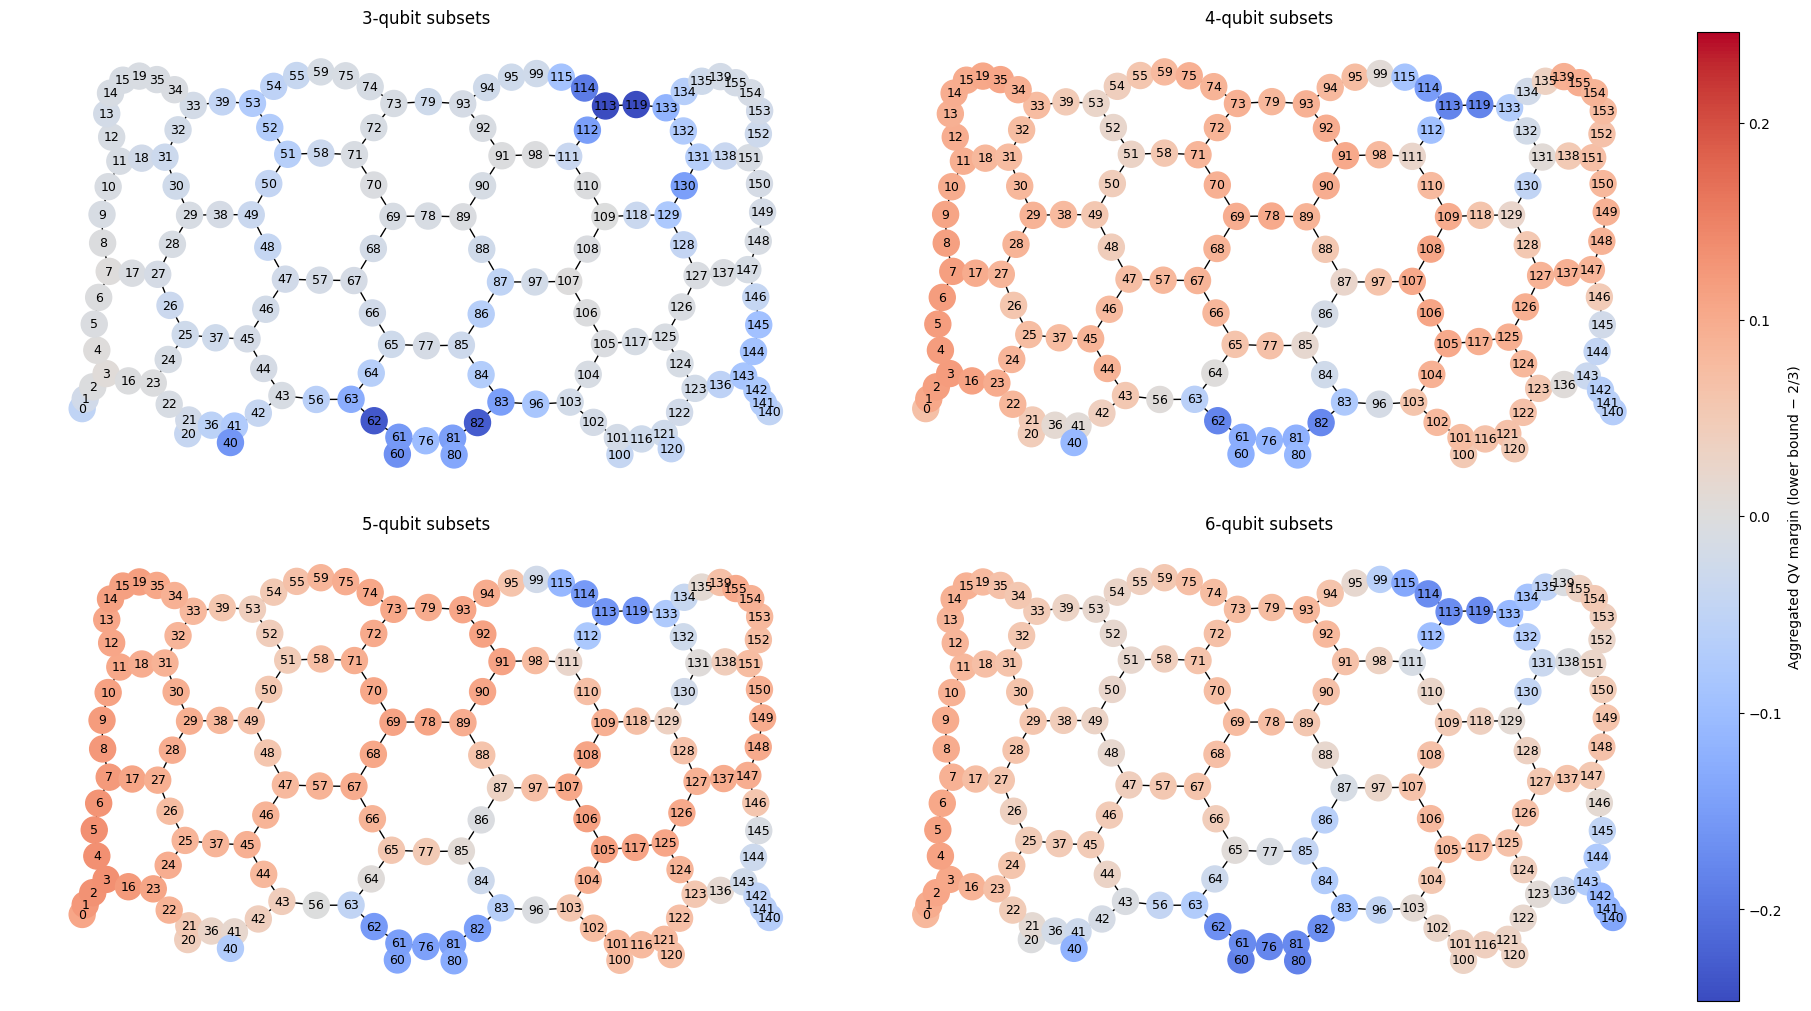

In [5]:
calibration = "calibrations/ibm_marrakesh/20260129_101824.json"
coupling_map = load_payload(calibration)["coupling_map"]

G = coupling_to_graph(coupling_map)
pos = graphviz_layout(G, prog="sfdp")

dfs_by_q = {}
for q in [3, 4, 5, 6]:
    dfs_by_q[q] = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples_optimised.csv")

plot_aggregated_qv_grid(G, pos, dfs_by_q)

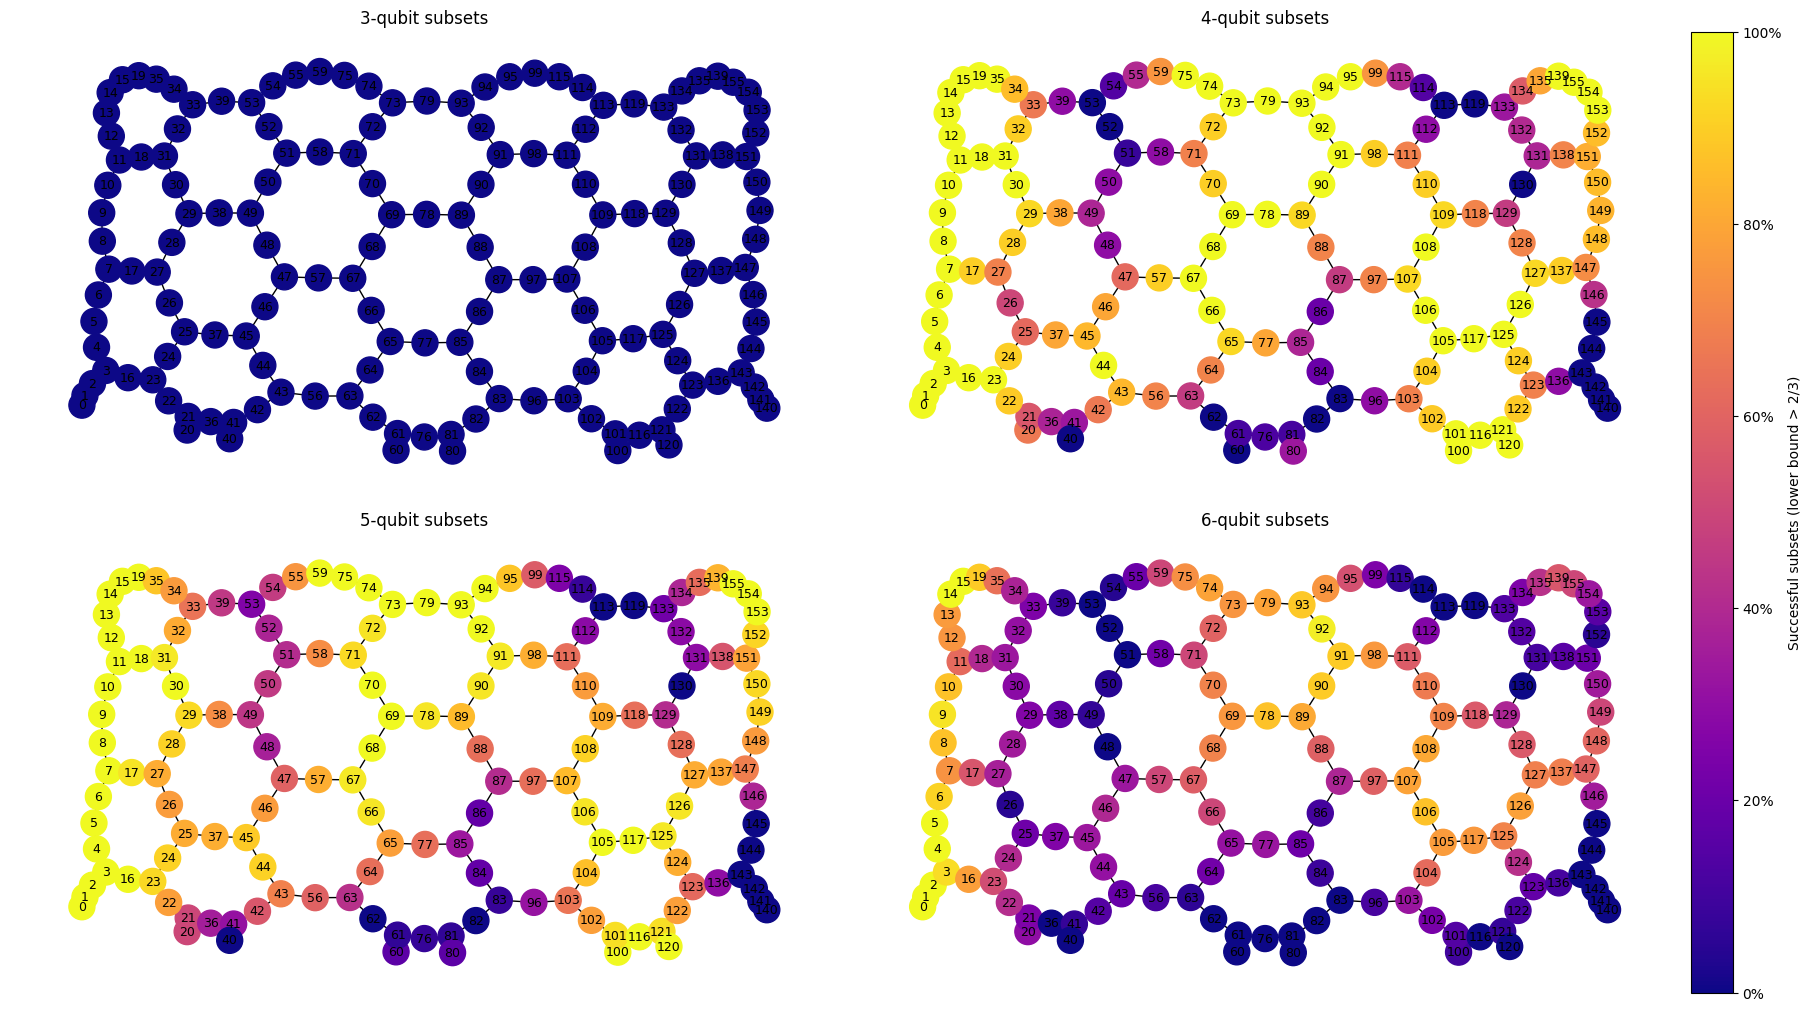

In [6]:
dfs_by_q = {}
for q in [3, 4, 5, 6]:
    dfs_by_q[q] = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples_optimised.csv")

plot_qv_success_fraction_grid(G, pos, dfs_by_q)

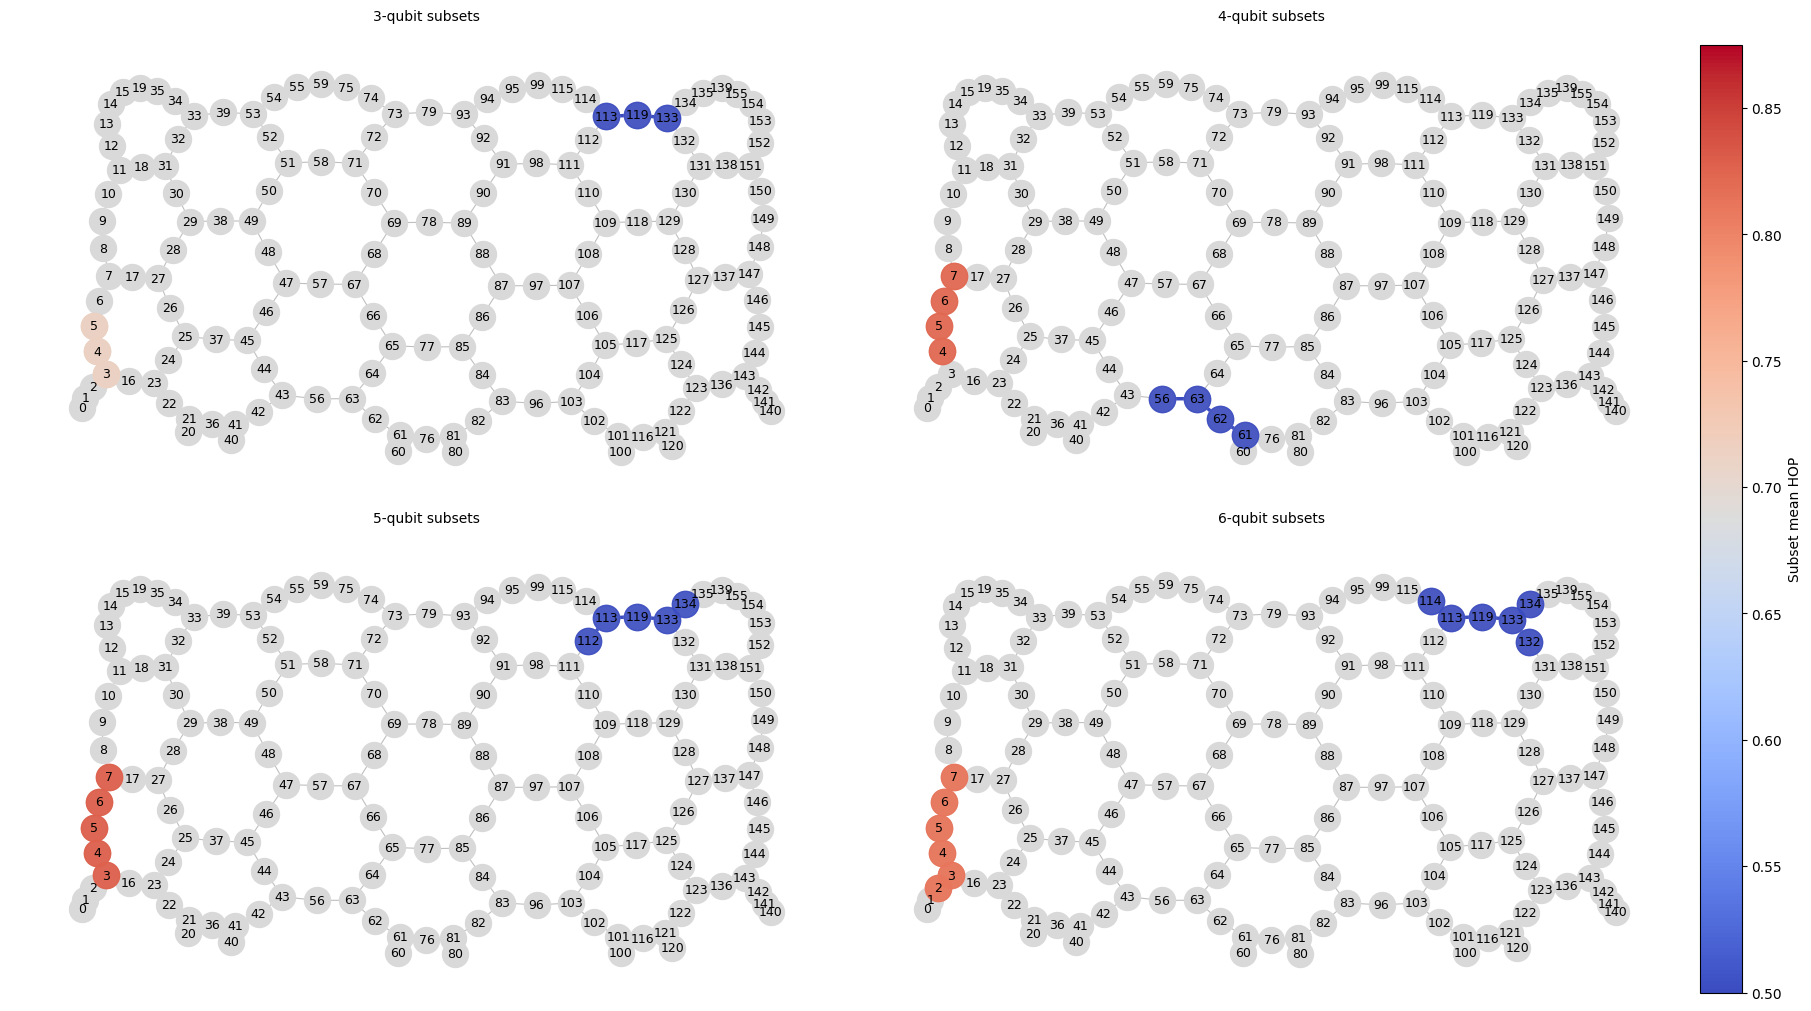

In [7]:
dfs_by_q = {}
for q in [3, 4, 5, 6]:
    dfs_by_q[q] = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples_optimised.csv")

plot_best_worst_grid(G, pos, dfs_by_q)

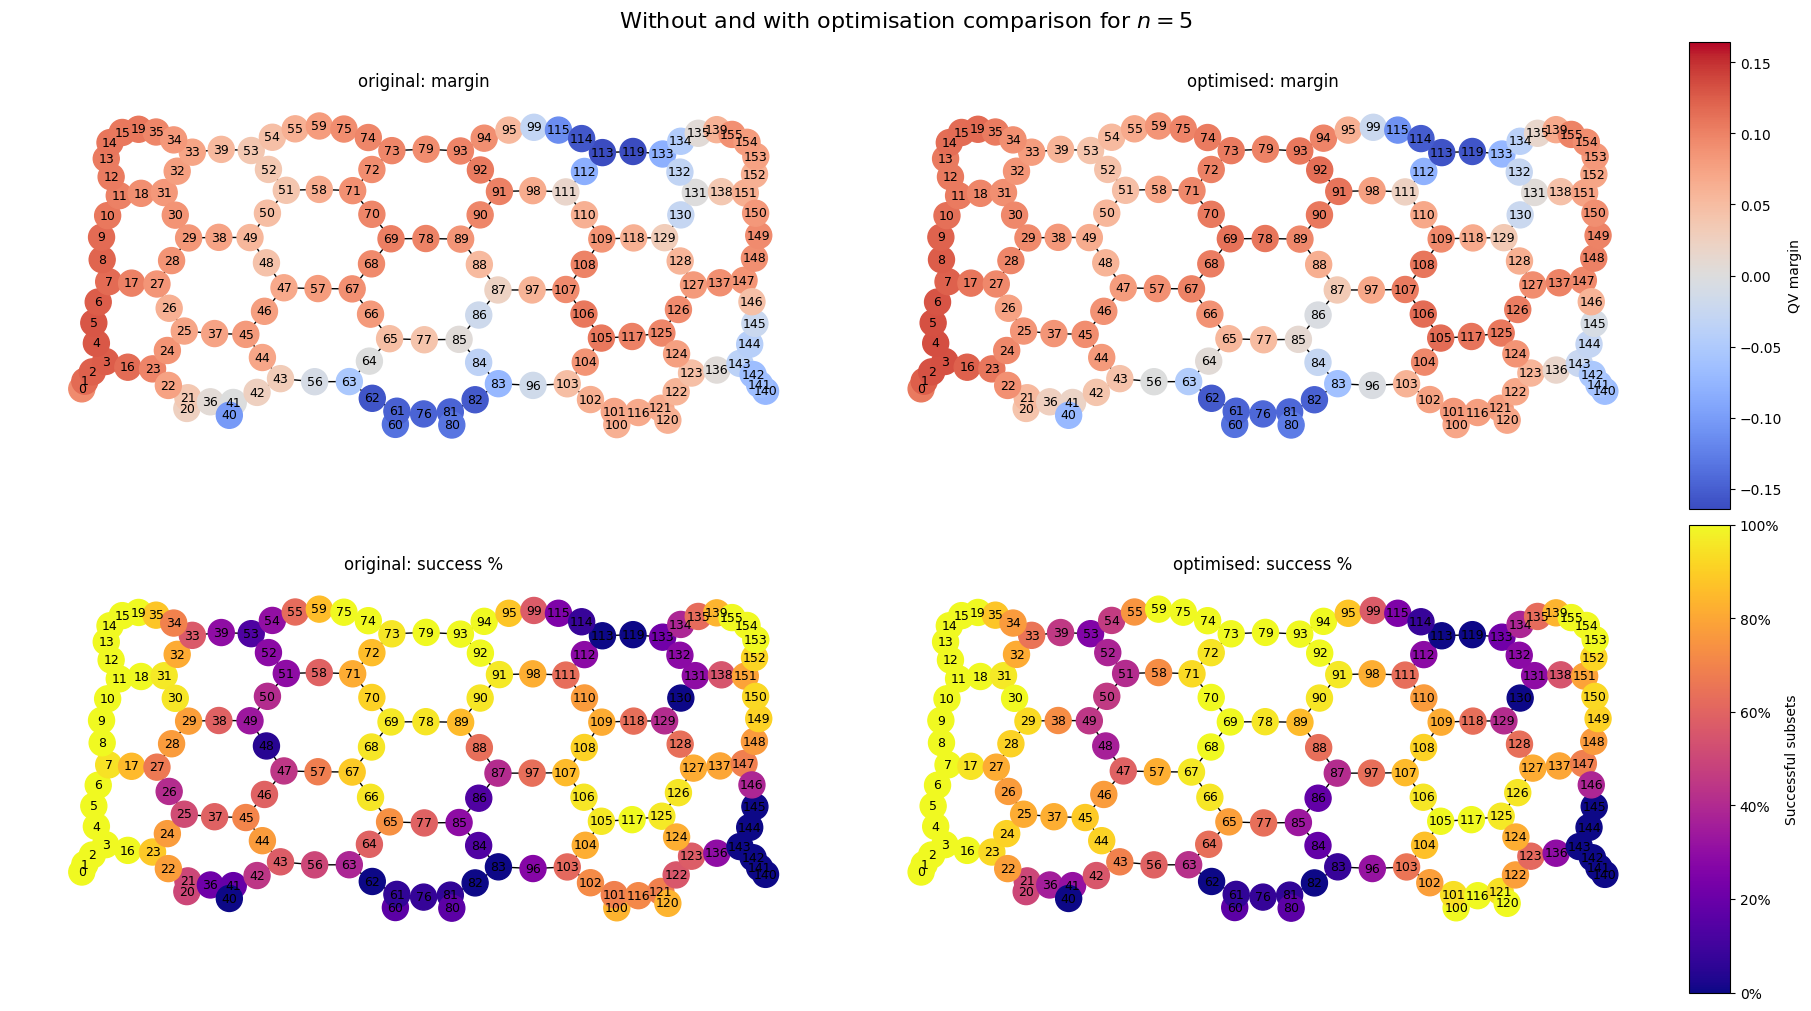

In [8]:
dfs_by_mode = {
    "original": pd.read_csv(f"results/ibm_marrakesh_qv_5_tuples.csv"),
    "optimised": pd.read_csv(f"results/ibm_marrakesh_qv_5_tuples_optimised.csv")
}

plot_mode_comparison_grid(G, pos, dfs_by_mode, q=5)

In [9]:
dfs = []

for n in [3, 4, 5, 6]:
    df = pd.read_csv(f"results/transpile_compare_{n}_tuples.csv")
    df["n"] = n
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

summary = df_all.groupby(["n", "variant"]).agg({
    "depth": ["mean", "std"],
    "size": ["mean"],
    "two_qubit_gates": ["mean"],
    "swap_ops": ["mean", "std"],
}).round(2)

summary = summary.reset_index()
summary.columns = [
    "n", "variant",
    "depth_mean", "depth_std",
    "size_mean",
    "two_qubit_gates_mean",
    "swap_ops_mean", "swap_ops_std"
]

summary.to_latex(
    "results/transpile_compare_summary.tex",
    index=False,
    escape=False
)

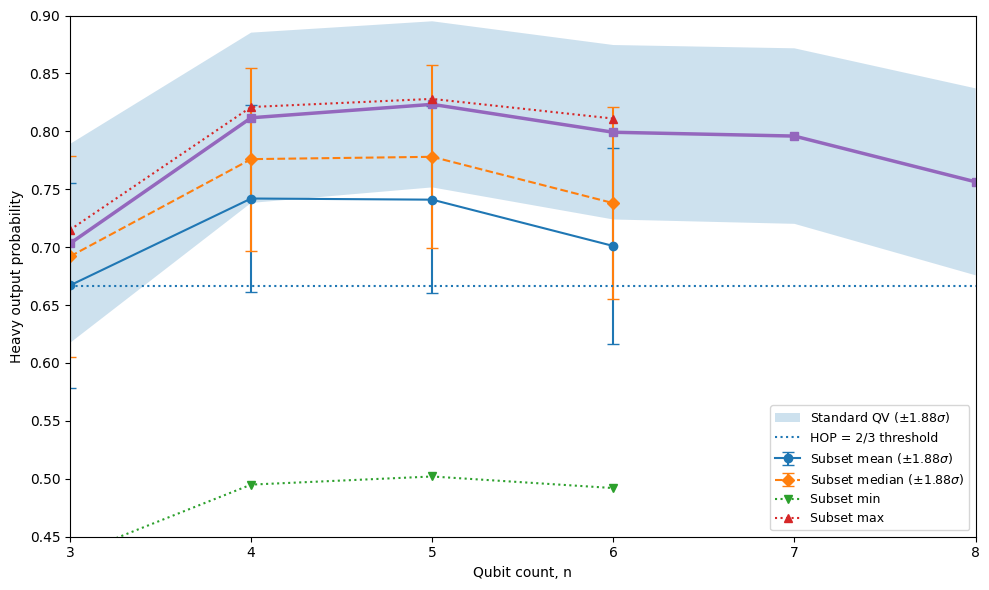

In [10]:
plot_qv_summary_stats()

In [11]:
dfs_by_q = {}
for q in [3, 4, 5, 6]:
    dfs_by_q[q] = pd.read_csv(f"results/ibm_marrakesh_qv_{q}_tuples_optimised.csv")

compute_node_metrics(dfs_by_q)

In [12]:
calib_df = load_calibration_csv("calibrations/errors.csv")
qv_df = pd.read_csv("results/all_node_metrics.csv")

merged = qv_df.merge(calib_df, on="node", how="left")
merged.to_csv("results/all_node_metrics.csv", index=False)

In [13]:
build_correlation_table_latex()

In [14]:
plot_node_metric_correlations()